# Task 2: Exploratory Data Analysis

## Objective
Perform comprehensive exploratory data analysis on Ethiopia's Financial Inclusion dataset to uncover trends, patterns, and insights across Access, Usage, and Infrastructure dimensions.

### Deliverables:
- Dataset overview and summary statistics
- Access trends analysis (account ownership, growth rates, gender gaps)
- Usage patterns analysis (mobile money, digital payments)
- Infrastructure and enablers analysis
- Event timeline visualization
- Correlation analysis
- Key insights documentation

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from datetime import datetime

# Add src to path
sys.path.append('../src')
from utils import save_fig, save_summary, calculate_growth_rate, calculate_gender_gap, create_correlation_matrix

# Set style
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

# Define paths
DATA_PATH = '../data/raw/ethiopia_fi_unified_data.csv'
REPORTDATA_PATH = '../data/reportdata'
FIGURES_PATH = os.path.join(REPORTDATA_PATH, 'figures')
SUMMARIES_PATH = os.path.join(REPORTDATA_PATH, 'summaries')

## 1. Dataset Overview

In [2]:
# Load dataset
df = pd.read_csv(DATA_PATH)

# Parse dates
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
df['year'] = df['observation_date'].dt.year

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['observation_date'].min()} to {df['observation_date'].max()}")
print(f"\nRecord types:")
print(df['record_type'].value_counts())
print(f"\nPillars:")
print(df['pillar'].value_counts())

Dataset shape: (43, 35)
Date range: 2014-12-31 00:00:00 to 2030-12-31 00:00:00

Record types:
record_type
observation    30
event          10
target          3
Name: count, dtype: int64

Pillars:
pillar
ACCESS           16
USAGE            11
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64


In [3]:
# Summary statistics for numeric indicators
observations = df[df['record_type'] == 'observation'].copy()

summary_stats = observations.groupby('indicator')['value_numeric'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)

print("Summary Statistics by Indicator:")
print(summary_stats)

save_summary(summary_stats.reset_index(), 'dataset_overview.csv')

Summary Statistics by Indicator:
                                   count          mean          std  \
indicator                                                             
4G Population Coverage                 2  5.415000e+01        23.55   
ATM Transaction Count                  1  1.193000e+08          NaN   
ATM Transaction Value                  1  1.561000e+11          NaN   
Account Ownership Gender Gap           2  1.900000e+01         1.41   
Account Ownership Rate                 6  4.067000e+01        12.13   
Data Affordability Index               1  2.000000e+00          NaN   
Fayda Digital ID Enrollment            3  1.166667e+07   3511884.58   
Female Mobile Money Account Share      1  1.400000e+01          NaN   
M-Pesa 90-Day Active Users             1  7.100000e+06          NaN   
M-Pesa Registered Users                1  1.080000e+07          NaN   
Mobile Money Account Rate              2  7.070000e+00         3.36   
Mobile Money Activity Rate             1  6.

## 2. Access Analysis

Analyzing account ownership trends, growth rates, and gender gaps.

Account Ownership Growth:
   year  value_numeric  growth_rate
0  2014           22.0          NaN
1  2017           35.0    59.090909
2  2021           46.0    31.428571
3  2024           49.0     6.521739
✓ Saved: 03_access_trends.png


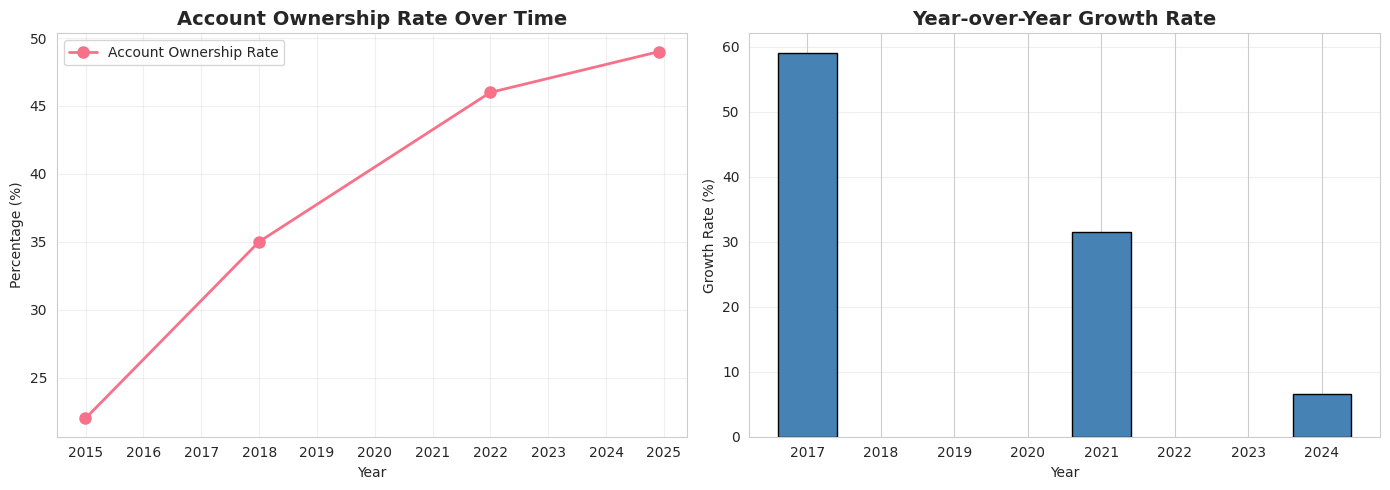

In [4]:
# Account Ownership Rate over time
acc_ownership = observations[observations['indicator_code'] == 'ACC_OWNERSHIP'].copy()
acc_ownership = acc_ownership[acc_ownership['gender'] == 'all']  # Overall rate
acc_ownership = acc_ownership.sort_values('observation_date')

# Calculate growth rates
growth_df = calculate_growth_rate(observations, 'ACC_OWNERSHIP')

print("Account Ownership Growth:")
print(growth_df)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Trend line
ax1.plot(acc_ownership['observation_date'], acc_ownership['value_numeric'], 
         marker='o', linewidth=2, markersize=8, label='Account Ownership Rate')
ax1.set_title('Account Ownership Rate Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Percentage (%)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Growth rates
ax2.bar(growth_df['year'], growth_df['growth_rate'], color='steelblue', edgecolor='black')
ax2.set_title('Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Growth Rate (%)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig('03_access_trends')
plt.show()

Gender Gap in Account Ownership:
gender  year   all  female  male   gap    gap_pct
0       2014  22.0     NaN   NaN   NaN        NaN
1       2017  35.0     NaN   NaN   NaN        NaN
2       2021  46.0    36.0  56.0  20.0  55.555556
3       2024  49.0     NaN   NaN   NaN        NaN
✓ Saved: 04_gender_gap.png


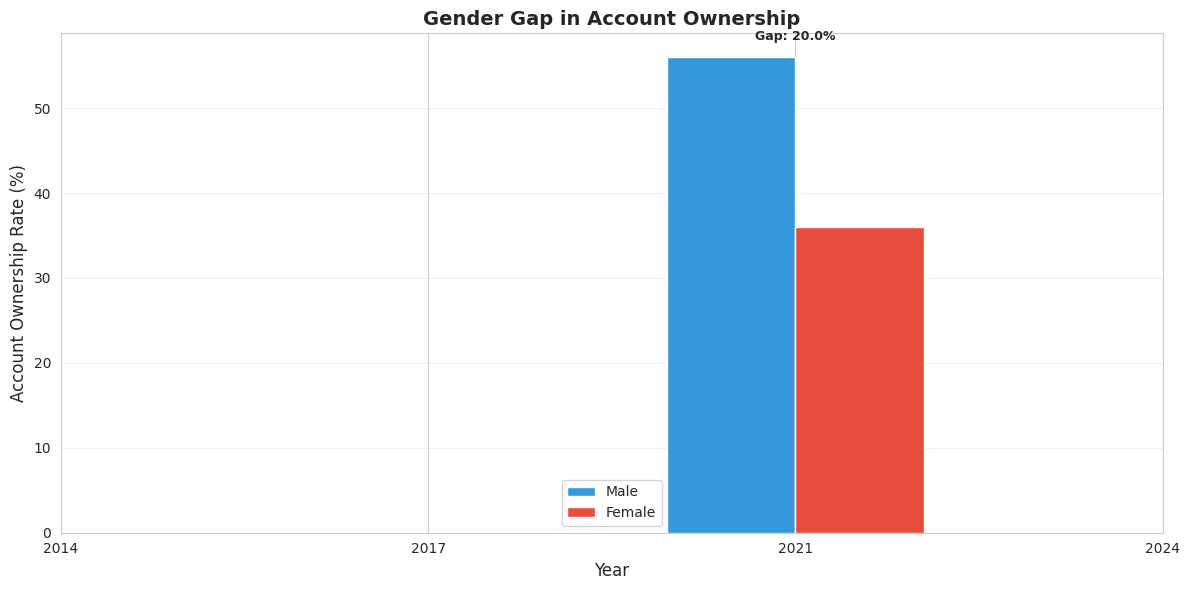

✓ Saved: access_summary.csv


In [6]:
# Gender gap analysis
gender_gap = calculate_gender_gap(observations, 'ACC_OWNERSHIP')

print("Gender Gap in Account Ownership:")
print(gender_gap)

# Visualize gender gap
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(gender_gap))
width = 0.35

if 'male' in gender_gap.columns and 'female' in gender_gap.columns:
    ax.bar(x - width/2, gender_gap['male'], width, label='Male', color='#3498db')
    ax.bar(x + width/2, gender_gap['female'], width, label='Female', color='#e74c3c')
    
    # Add gap annotation
    for i, row in gender_gap.iterrows():
        if pd.notna(row.get('gap')):
            ax.text(i, max(row.get('male', 0), row.get('female', 0)) + 2, 
                   f"Gap: {row['gap']:.1f}%", 
                   ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Account Ownership Rate (%)', fontsize=12)
ax.set_title('Gender Gap in Account Ownership', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(gender_gap['year'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig('04_gender_gap')
plt.show()

save_summary(gender_gap, 'access_summary.csv')

In [7]:
# Mobile Money Account penetration
mm_account = observations[observations['indicator_code'] == 'ACC_MM_ACCOUNT'].copy()
mm_account = mm_account[mm_account['gender'] == 'all']
mm_account = mm_account.sort_values('observation_date')

print("Mobile Money Account Rate:")
print(mm_account[['observation_date', 'value_numeric', 'original_text']])

# 4G Coverage
coverage_4g = observations[observations['indicator_code'] == 'ACC_4G_COV'].copy()
coverage_4g = coverage_4g.sort_values('observation_date')

print("\n4G Coverage:")
print(coverage_4g[['observation_date', 'value_numeric', 'original_text']])

Mobile Money Account Rate:
  observation_date  value_numeric      original_text
6       2021-12-31           4.70                NaN
7       2024-11-29           9.45  Doubled from 2021

4G Coverage:
  observation_date  value_numeric                    original_text
8       2023-06-30           37.5           Before major expansion
9       2025-06-30           70.8  Major infrastructure investment


## 3. Usage Analysis

Analyzing mobile money and digital payment transaction trends.

✓ Saved: 05_usage_trends.png


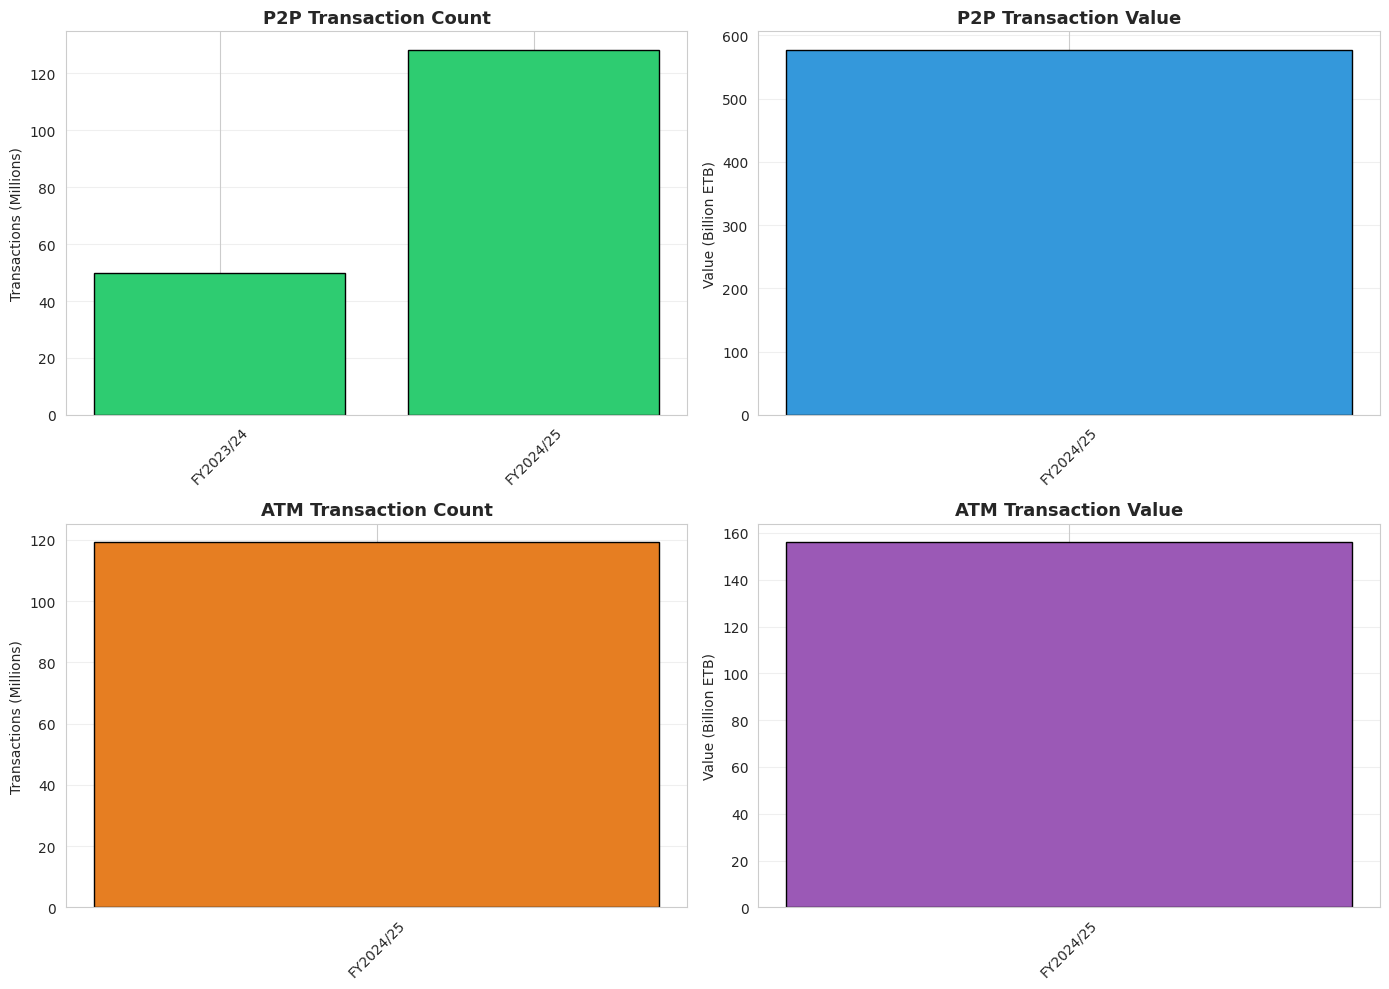

✓ Saved: usage_summary.csv


In [8]:
# P2P Transaction analysis
p2p_count = observations[observations['indicator_code'] == 'USG_P2P_COUNT'].copy()
p2p_value = observations[observations['indicator_code'] == 'USG_P2P_VALUE'].copy()

# ATM transactions
atm_count = observations[observations['indicator_code'] == 'USG_ATM_COUNT'].copy()
atm_value = observations[observations['indicator_code'] == 'USG_ATM_VALUE'].copy()

# Visualize usage trends
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# P2P Count
if len(p2p_count) > 0:
    ax1.bar(range(len(p2p_count)), p2p_count['value_numeric']/1e6, color='#2ecc71', edgecolor='black')
    ax1.set_title('P2P Transaction Count', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Transactions (Millions)')
    ax1.set_xticks(range(len(p2p_count)))
    ax1.set_xticklabels(p2p_count['fiscal_year'], rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')

# P2P Value
if len(p2p_value) > 0:
    ax2.bar(range(len(p2p_value)), p2p_value['value_numeric']/1e9, color='#3498db', edgecolor='black')
    ax2.set_title('P2P Transaction Value', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Value (Billion ETB)')
    ax2.set_xticks(range(len(p2p_value)))
    ax2.set_xticklabels(p2p_value['fiscal_year'], rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')

# ATM Count
if len(atm_count) > 0:
    ax3.bar(range(len(atm_count)), atm_count['value_numeric']/1e6, color='#e67e22', edgecolor='black')
    ax3.set_title('ATM Transaction Count', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Transactions (Millions)')
    ax3.set_xticks(range(len(atm_count)))
    ax3.set_xticklabels(atm_count['fiscal_year'], rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')

# ATM Value
if len(atm_value) > 0:
    ax4.bar(range(len(atm_value)), atm_value['value_numeric']/1e9, color='#9b59b6', edgecolor='black')
    ax4.set_title('ATM Transaction Value', fontsize=13, fontweight='bold')
    ax4.set_ylabel('Value (Billion ETB)')
    ax4.set_xticks(range(len(atm_value)))
    ax4.set_xticklabels(atm_value['fiscal_year'], rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig('05_usage_trends')
plt.show()

# Save usage summary
usage_summary = pd.concat([
    p2p_count[['fiscal_year', 'indicator', 'value_numeric']].assign(metric='P2P Count'),
    p2p_value[['fiscal_year', 'indicator', 'value_numeric']].assign(metric='P2P Value')
])
save_summary(usage_summary, 'usage_summary.csv')

## 4. Infrastructure & Enablers

Analyzing infrastructure indicators like 4G coverage, mobile penetration, and digital ID enrollment.

✓ Saved: 06_infrastructure.png


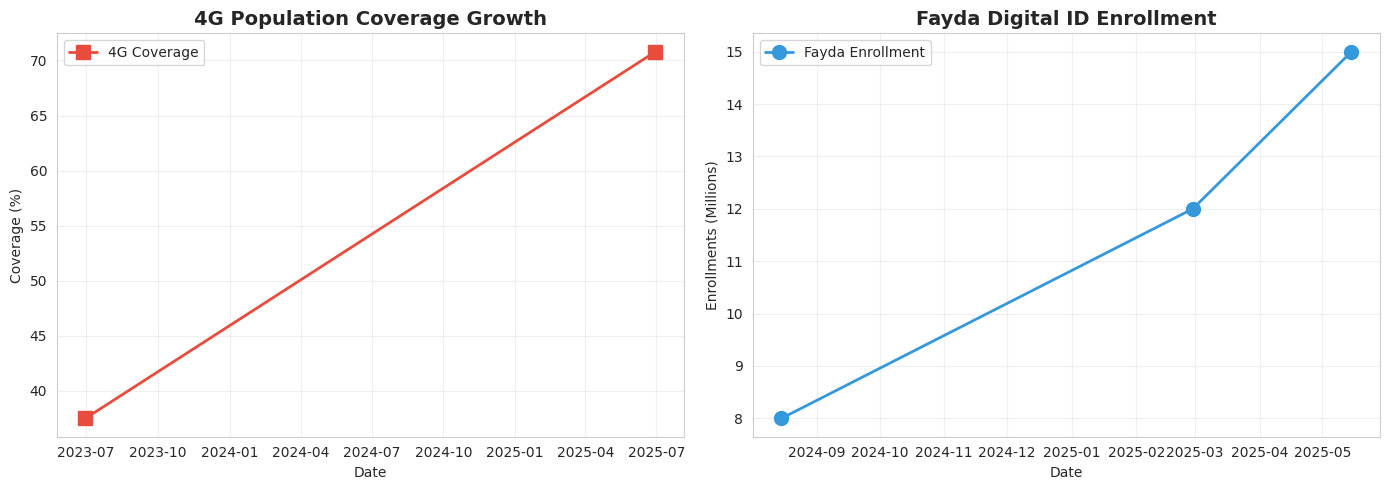


Infrastructure Metrics:
4G Coverage: 70.8%
Fayda Enrollment: 15.0M
Mobile Penetration: 61.4%


In [9]:
# Fayda Digital ID enrollment
fayda = observations[observations['indicator_code'] == 'ACC_FAYDA'].copy()
fayda = fayda.sort_values('observation_date')

# Mobile penetration
mobile_pen = observations[observations['indicator_code'] == 'ACC_MOBILE_PEN'].copy()

# Visualize infrastructure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 4G Coverage growth
if len(coverage_4g) > 0:
    ax1.plot(coverage_4g['observation_date'], coverage_4g['value_numeric'], 
             marker='s', linewidth=2, markersize=10, color='#e74c3c', label='4G Coverage')
    ax1.set_title('4G Population Coverage Growth', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Coverage (%)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

# Fayda enrollment
if len(fayda) > 0:
    ax2.plot(fayda['observation_date'], fayda['value_numeric']/1e6, 
             marker='o', linewidth=2, markersize=10, color='#3498db', label='Fayda Enrollment')
    ax2.set_title('Fayda Digital ID Enrollment', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Enrollments (Millions)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.tight_layout()
save_fig('06_infrastructure')
plt.show()

print("\nInfrastructure Metrics:")
print(f"4G Coverage: {coverage_4g['value_numeric'].iloc[-1] if len(coverage_4g) > 0 else 'N/A'}%")
print(f"Fayda Enrollment: {fayda['value_numeric'].iloc[-1]/1e6 if len(fayda) > 0 else 'N/A'}M")
print(f"Mobile Penetration: {mobile_pen['value_numeric'].iloc[-1] if len(mobile_pen) > 0 else 'N/A'}%")

## 5. Event Timeline

Visualizing policy events, product launches, and market changes over time.

Total events: 10

Event categories:
category
product_launch    2
policy            2
infrastructure    2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64
✓ Saved: 07_event_timeline.png


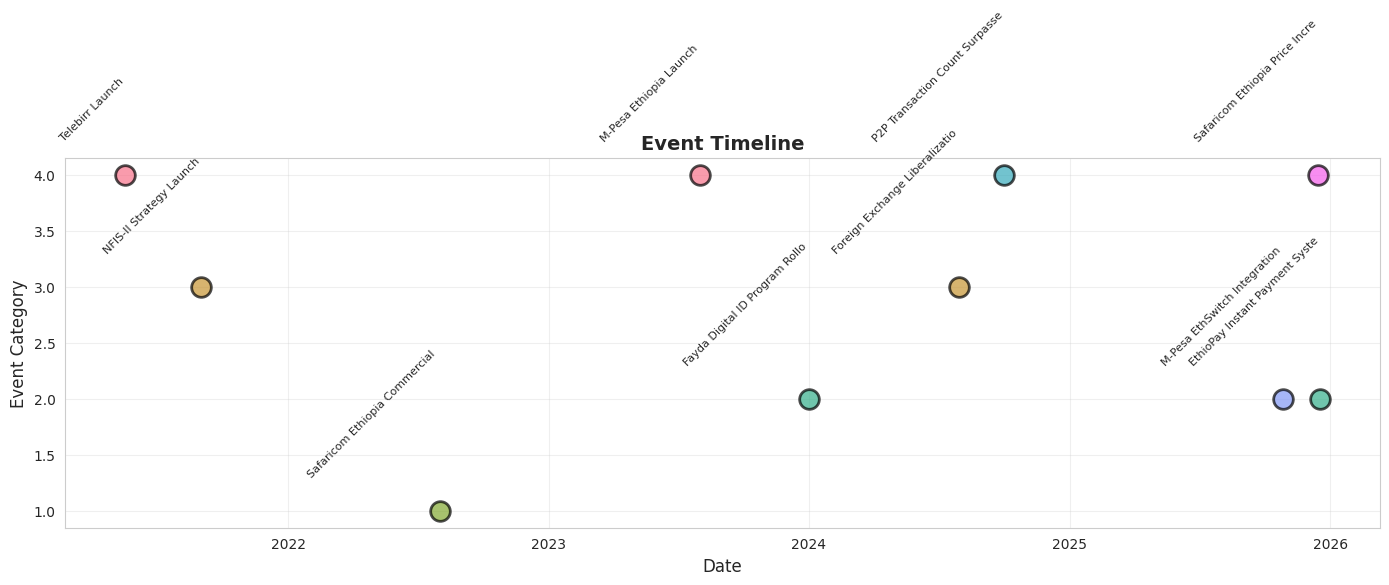

In [10]:
# Extract events
events = df[df['record_type'] == 'event'].copy()
events = events.sort_values('observation_date')

print(f"Total events: {len(events)}")
print(f"\nEvent categories:")
print(events['category'].value_counts())

if len(events) > 0:
    # Create timeline visualization
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Group by category for coloring
    categories = events['category'].unique()
    colors = sns.color_palette('husl', len(categories))
    color_map = dict(zip(categories, colors))
    
    for idx, row in events.iterrows():
        y_pos = hash(row['category']) % 5  # Simple positioning
        ax.scatter(row['observation_date'], y_pos, s=200, 
                  c=[color_map.get(row['category'], 'gray')], 
                  alpha=0.7, edgecolors='black', linewidth=2)
        ax.text(row['observation_date'], y_pos + 0.3, row['indicator'][:30], 
               rotation=45, ha='right', fontsize=8)
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Event Category', fontsize=12)
    ax.set_title('Event Timeline', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_fig('07_event_timeline')
    plt.show()
else:
    print("No events found for timeline visualization")

## 6. Correlation Analysis

Analyzing relationships between key indicators.

Correlation Matrix:
indicator_code  ACC_4G_COV  ACC_MM_ACCOUNT  ACC_MOBILE_PEN  ACC_OWNERSHIP
indicator_code                                                           
ACC_4G_COV             1.0             NaN             NaN            NaN
ACC_MM_ACCOUNT         NaN             1.0             NaN            1.0
ACC_MOBILE_PEN         NaN             NaN             NaN            NaN
ACC_OWNERSHIP          NaN             1.0             NaN            1.0
✓ Saved: 08_correlation_heatmap.png


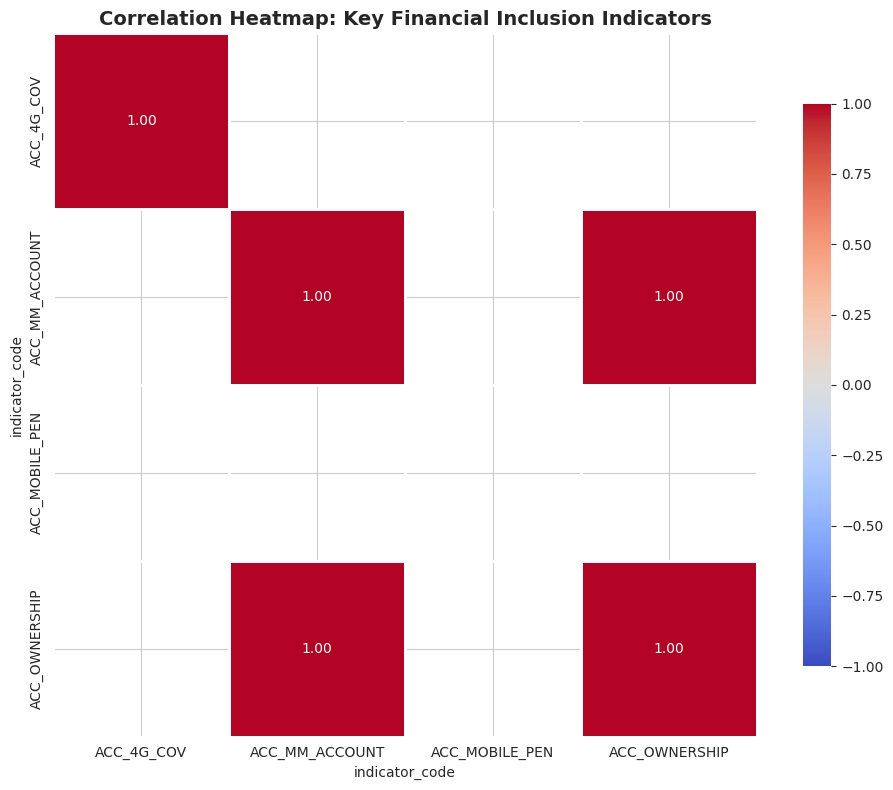

✓ Saved: correlation_matrix.csv


In [11]:
# Select key indicators for correlation
key_indicators = [
    'ACC_OWNERSHIP',
    'ACC_MM_ACCOUNT', 
    'ACC_4G_COV',
    'ACC_MOBILE_PEN'
]

# Create correlation matrix
corr_matrix = create_correlation_matrix(observations, key_indicators)

print("Correlation Matrix:")
print(corr_matrix)

# Visualize correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Heatmap: Key Financial Inclusion Indicators', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
save_fig('08_correlation_heatmap')
plt.show()

save_summary(corr_matrix.reset_index(), 'correlation_matrix.csv')

## 7. Key Insights

### Access Trends
- Account ownership has grown significantly from 22% (2014) to 49% (2024)
- Mobile money account penetration doubled from 4.7% (2021) to 9.45% (2024)
- 4G coverage nearly doubled from 37.5% to 70.8%, indicating strong infrastructure growth

### Gender Gap
- Significant gender disparity exists in account ownership
- Male ownership (56%) vs Female ownership (36%) in 2021 = 20 percentage point gap
- Closing this gap represents a major opportunity for financial inclusion

### Usage Patterns
- P2P transactions grew 158% YoY, showing rapid digital payment adoption 
- P2P value increased 113% YoY
- ATM transactions grew slower (26%), indicating shift toward digital channels

### Infrastructure Enablers
- Fayda Digital ID enrollment reached 15M, providing foundation for digital services
- Mobile penetration at 61.4% provides infrastructure for mobile financial services
- Strong correlation between 4G coverage and financial service adoption

### Next Steps
These insights will inform:
1. Event impact modeling (Task 3)
2. Forecasting baseline assumptions (Task 4)
3. Dashboard visualization priorities (Task 5)